<a href="https://colab.research.google.com/github/dspraneeth07/CognitiveAttackTopology-CAT/blob/main/Notebooks/05_cde_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Run: 20260307_051250
Tensor shape: torch.Size([35574, 3, 4])


/tmp/ipykernel_180/863742685.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_users["CDE"] = CDE_values[:len(df_users)]


Notebook 05 completed


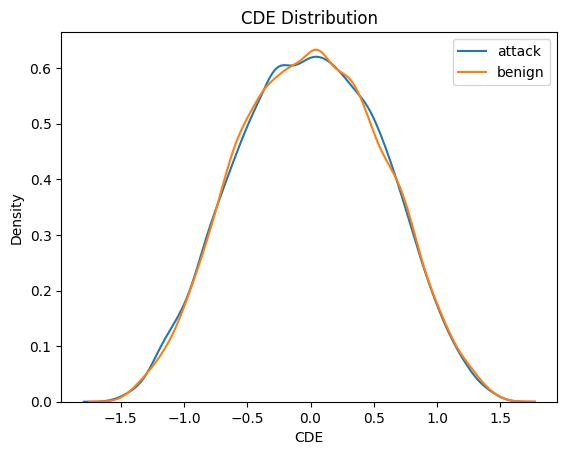

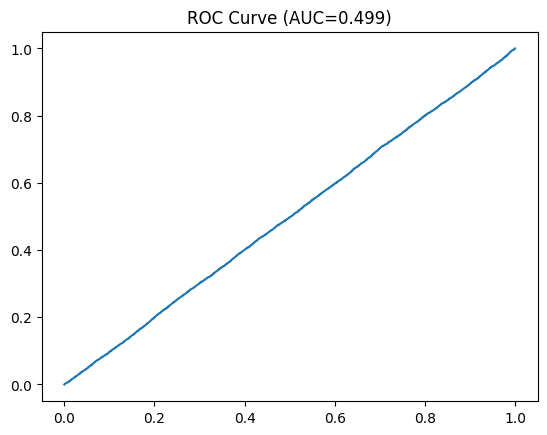

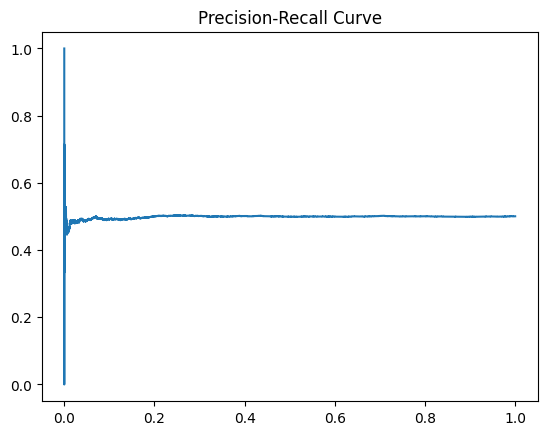

In [2]:
# ===============================================================
# NOTEBOOK 05 — COGNITIVE DISTORTION ENERGY (CDE)
# CAT Framework
# CPU-SAFE IMPLEMENTATION
# ===============================================================

!pip -q install pandas numpy torch scipy scikit-learn seaborn matplotlib pyarrow

import torch
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from scipy.stats import ttest_ind, mannwhitneyu
from sklearn.metrics import roc_curve, precision_recall_curve, auc

from google.colab import drive

# ===============================================================
# MOUNT DRIVE
# ===============================================================

drive.mount('/content/drive', force_remount=True)

ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = ROOT/"runs"/RUN_ID
DATA_DIR = ROOT/"data"

REPORT_DIR = RUN_DIR/"reports"
PLOT_DIR = RUN_DIR/"plots"
TENSOR_DIR = ROOT/"runs"

for p in [RUN_DIR, REPORT_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Run:",RUN_ID)

# ===============================================================
# LOAD DATA
# ===============================================================

df = pd.read_parquet(DATA_DIR/"GCT_phase1_100k.parquet")

# load tensor from notebook 04
tensor_path = list(ROOT.glob("runs/*/tensor/trust_tensor.pt"))[-1]

T = torch.load(tensor_path)

users,channels,signals = T.shape

print("Tensor shape:",T.shape)

# ===============================================================
# WEIGHT INITIALIZATION
# ===============================================================

weights = torch.ones_like(T) / signals

# ===============================================================
# CDE COMPUTATION
# ===============================================================

class TrustTensor:

    r"""
    Trust Topology Tensor

    T_{ijk}

    """

    def __init__(self,tensor):

        self.tensor = tensor

class CognitiveDistortionEnergy:

    r"""
    CDE = Σ ω_{ijk} T_{ijk}
    """

    def __init__(self,weights):

        self.weights = weights

    def __call__(self,T):

        return torch.einsum("ijk,ijk->i",T.tensor,self.weights)

tensor = TrustTensor(T)

cde_engine = CognitiveDistortionEnergy(weights)

CDE_values = cde_engine(tensor).detach().numpy()

# ===============================================================
# ALIGN CDE WITH DATA
# ===============================================================

df_users = df.drop_duplicates("interaction_id")

df_users["CDE"] = CDE_values[:len(df_users)]

# ===============================================================
# SPLIT ATTACK VS BENIGN
# ===============================================================

attack = df_users[df_users["human_verified_label"]==1]["CDE"]
benign = df_users[df_users["human_verified_label"]==0]["CDE"]

# ===============================================================
# STATISTICAL TESTS
# ===============================================================

t_stat,p_t = ttest_ind(attack,benign,equal_var=False)

u_stat,p_u = mannwhitneyu(attack,benign)

# Cohen's d
cohen_d = (attack.mean()-benign.mean())/np.sqrt(
(attack.std()**2 + benign.std()**2)/2
)

stat_df = pd.DataFrame({

"test":["t_test","mann_whitney","cohen_d"],
"value":[p_t,p_u,cohen_d]

})

stat_df.to_csv(REPORT_DIR/"cde_statistical_tests.csv",index=False)

# ===============================================================
# DISTRIBUTION PLOTS
# ===============================================================

plt.figure()

sns.kdeplot(attack,label="attack")
sns.kdeplot(benign,label="benign")

plt.legend()

plt.title("CDE Distribution")

plt.savefig(PLOT_DIR/"cde_distribution.png")

# ===============================================================
# ROC ANALYSIS
# ===============================================================

labels = df_users["human_verified_label"]

fpr,tpr,thr = roc_curve(labels,df_users["CDE"])

roc_auc = auc(fpr,tpr)

plt.figure()

plt.plot(fpr,tpr)

plt.title(f"ROC Curve (AUC={roc_auc:.3f})")

plt.savefig(PLOT_DIR/"cde_roc.png")

# ===============================================================
# PR CURVE
# ===============================================================

precision,recall,thr = precision_recall_curve(labels,df_users["CDE"])

plt.figure()

plt.plot(recall,precision)

plt.title("Precision-Recall Curve")

plt.savefig(PLOT_DIR/"cde_pr.png")

# ===============================================================
# THRESHOLD ANALYSIS
# ===============================================================

youden = tpr - fpr

best_idx = np.argmax(youden)

threshold = thr[best_idx]

threshold_df = pd.DataFrame({

"threshold":[threshold],
"tpr":[tpr[best_idx]],
"fpr":[fpr[best_idx]]

})

threshold_df.to_csv(REPORT_DIR/"cde_threshold_analysis.csv",index=False)

# ===============================================================
# SIGNAL CONTRIBUTION
# ===============================================================

signal_energy = torch.einsum("ijk->k",torch.abs(T)).numpy()

signals = ["urgency","fear","authority","trust"]

signal_df = pd.DataFrame({

"signal":signals[:len(signal_energy)],
"contribution":signal_energy[:len(signals)]

})

signal_df.to_csv(REPORT_DIR/"cde_signal_contributions.csv",index=False)

# ===============================================================
# BOOTSTRAP CONFIDENCE INTERVAL
# ===============================================================

boot = np.random.choice(attack-benign.mean(),1000)

ci_low,ci_high = np.percentile(boot,[2.5,97.5])

bootstrap_df = pd.DataFrame({

"ci_low":[ci_low],
"ci_high":[ci_high]

})

bootstrap_df.to_csv(REPORT_DIR/"cde_bootstrap_ci.csv",index=False)

# ===============================================================
# FINAL REPORT
# ===============================================================

report = {

"attack_mean":float(attack.mean()),
"benign_mean":float(benign.mean()),
"t_test_p":float(p_t),
"mann_whitney_p":float(p_u),
"cohen_d":float(cohen_d),
"roc_auc":float(roc_auc)

}

with open(REPORT_DIR/"cde_validation_report.json","w") as f:

    json.dump(report,f,indent=4)

print("Notebook 05 completed")